Observing the influence of closure times using the difference between the 2019-07-03 free_PAH simulation (as the control) and the other 2019-07-03 simulations.

In [1]:
import os
import xarray as xr
import numpy as np
import itertools
import warnings
import pandas as pd
import seaborn as sns
from pathlib import Path
import geopandas as gpd
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import ssam_groups as groups
from mpl_toolkits.axes_grid1 import make_axes_locatable

warnings.simplefilter('ignore')

### Define scenario and control files

| Scenarios	| Label	| Description |
|-----------|-------|-------------|
| 1	| free_PAH |no containment or closures |
| 2 | 30d_closure |30-day fisheries closures |
| 3	| 90d_closure |90-day fisheries closures |
| 4	| 48h_contain	|containment within 48hrs |
| 5	| 48h_contain_30d_closure	|containment within 48hrs + 30-day fisheries closures |
| 6	| 48h_contain_90d_closure	|containment within 48hrs + 90-day fisheries closures |
| 7	| 180d_closure	|180-day fisheries closures |
| 8	| 270d_closure	|270-day fisheries closures |
| 9	| 365d_closure	|365-day fisheries closures |

### Scenario comparison across fished groups

In [37]:
scenario_palette = sns.color_palette([
'#863092', 
'#A464AD',
'#C297C8', 
'#A17170',
'#B39595',
'#DAC0DE', 
'#C0CFE5', 
])

In [3]:
df = pd.read_csv("/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI2/data_2019-07-03.csv")

In [31]:
test_scenarios =  [2,3,7,8,9]
df_plot = df.loc[df['scenario'].isin(test_scenarios)]

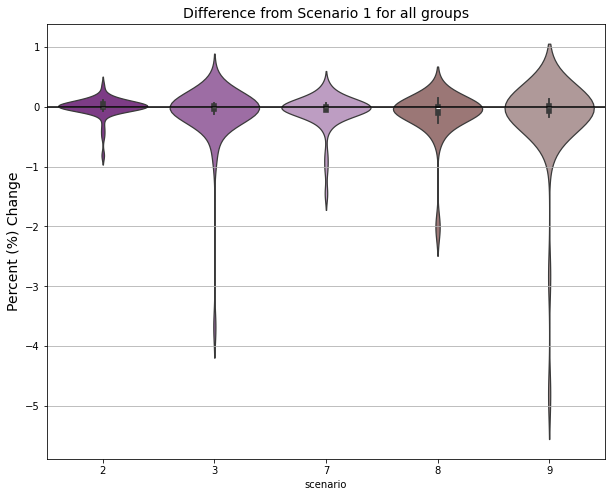

In [38]:
plt.figure(figsize=(10, 8))
plt.grid()
ax = sns.violinplot(df_plot, x="scenario", y="percent_change", palette=scenario_palette) 
plt.ylabel('Percent (%) Change', fontsize = 14)
#plt.xticks(rotation=90)
plt.title('Difference from Scenario 1 for all groups', fontsize = 14)
plt.axhline(0, color='k'); 

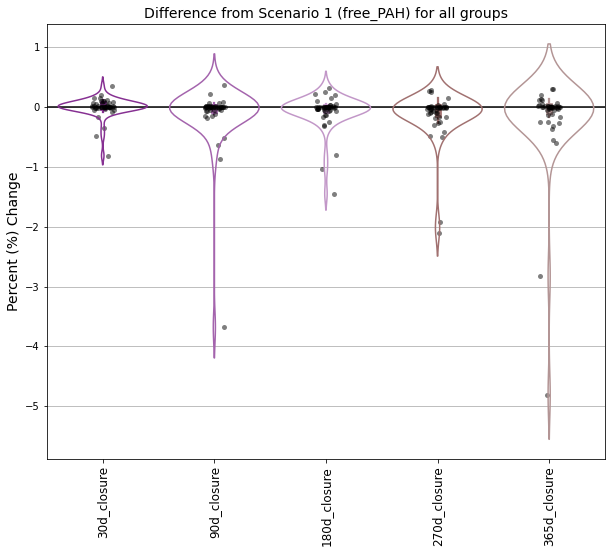

In [40]:
plt.figure(figsize=(10, 8)) 
plt.grid()
ax=sns.violinplot(df_plot, x="description", y="percent_change",
    palette=scenario_palette, hue='scenario', fill=False, zorder=10, legend=False) 
sns.stripplot(data=df_plot, x="description",
    y="percent_change", color='k', alpha=0.5, ax=ax)
plt.ylabel('Percent (%) Change', fontsize = 14)
plt.title('Difference from Scenario 1 (free_PAH) for all groups', fontsize = 14)
plt.axhline(0, color='k'); #linestyle='--'
plt.xlabel(None)
plt.xticks(rotation=90, fontsize=12);
#plt.savefig('Fig-results-scenarios.png',bbox_inches='tight',dpi=300);

biomass change per group

In [4]:
custom_order = ['macroalgae', 'seagrass', 'benthic grazers', 'other filter feeders', 'macrobenthos',  
    'sponges', 'bivalves', 'crabs', 'dungeness crabs',
    'pelagic bacteria', 'diatoms', 'picophytoplankton', 'microzooplankton', 
    'mesozooplankton', 'squid',  
    'small pelagic',  'small demersal', 'small flatfish', 
    'benthopelagic', 'large demersal', 'large flatfish','rockfish',
    'hake','lingcod', 'pollock', 'sandlance','pacific herring', 
    'Chinook', 'Chum', 'Coho','Pink','Sockeye', 'Other salmonids',
    'Hatchery Chinook','Hatchery Coho','Hatchery Sockeye',
    'dogfish','ratfish','sixgill','skates',
    'porpoises', 'seals', 'sealions',
    'resident orcas', 'transient orcas','humpbacks',
    'seagulls','other seabirds',]

In [5]:
bio_boundaries = [9, 15, 36, 40, 46]

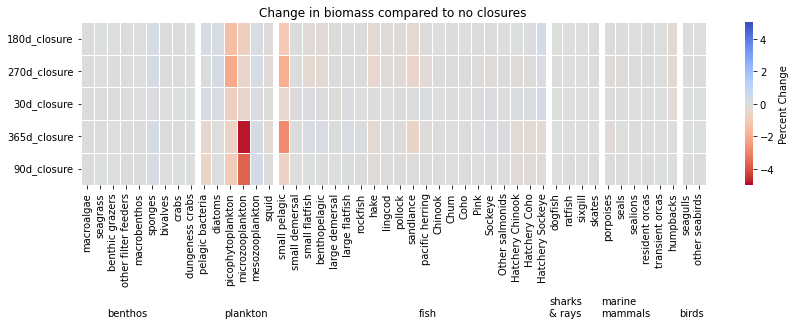

In [41]:
heatmap_data = df_plot.pivot(index='description', columns='bio_group', values='percent_change',)
heatmap_df = heatmap_data.reindex(columns=custom_order)
plt.figure(figsize=(14, 3))
ax = sns.heatmap(
heatmap_df, 
annot=False,
fmt=".1f",
cmap="coolwarm_r", 
center=0, vmin=-5, vmax=5,
linewidths=0.5, 
#linecolor='gray',
cbar_kws={'label': 'Percent Change'}
)
plt.xlabel(None)
plt.ylabel(None)
for x in bio_boundaries:
    ax.vlines(x, *ax.get_ylim(), colors='white', linewidth=6)
plt.title('Change in biomass compared to no closures')
#plt.title(groups.scenarios[str(scenario_label)])
y_position = 9
font_size = 10
plt.text(2, y_position, 'benthos', color='k', size=font_size,)
plt.text(11, y_position, 'plankton', color='k', size=font_size,)
plt.text(26, y_position, 'fish', color='k', size=font_size,)
plt.text(36, y_position, 'sharks\n& rays', color='k', size=font_size,)
plt.text(40, y_position, 'marine\nmammals', color='k', size=font_size,)
plt.text(46, y_position, 'birds', color='k', size=font_size,);